# CNN Emotion Classification - Experiment

## Sample Images

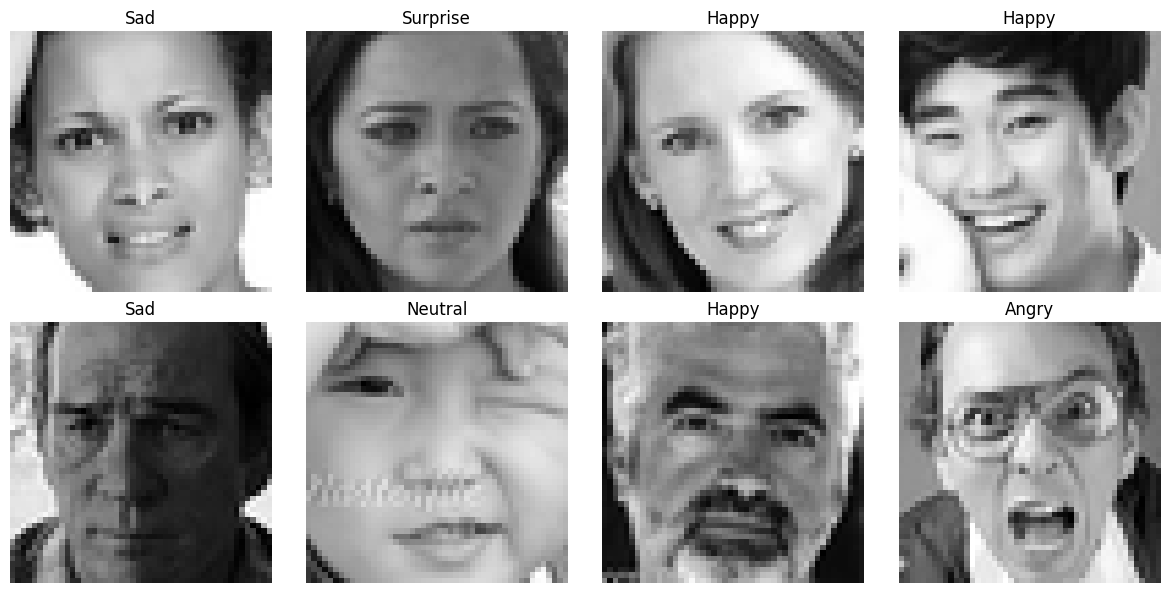

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import random

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")

indices = random.sample(range(len(val_dataset)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(FERDataset.class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Training Summary

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, SimpleCNN

_hist = ROOT / "train_losses.npy"
if not _hist.exists():
    raise FileNotFoundError(
        f"{_hist} not found. Run training from the repo root so metrics are saved, e.g.:\n"
        "  python src/main.py"
    )
train_losses = np.load(ROOT / "train_losses.npy")
val_losses = np.load(ROOT / "val_losses.npy")
val_accuracies = np.load(ROOT / "val_accuracies.npy")

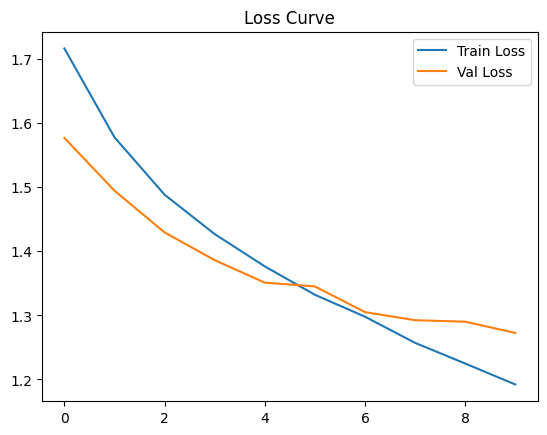

In [6]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

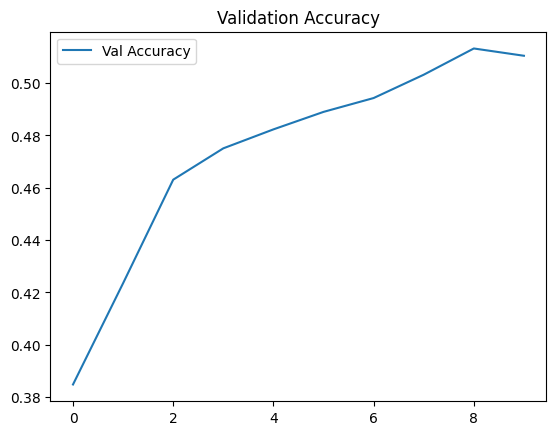

In [7]:
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

Best Val Accuracy: 0.5132

## Predictions

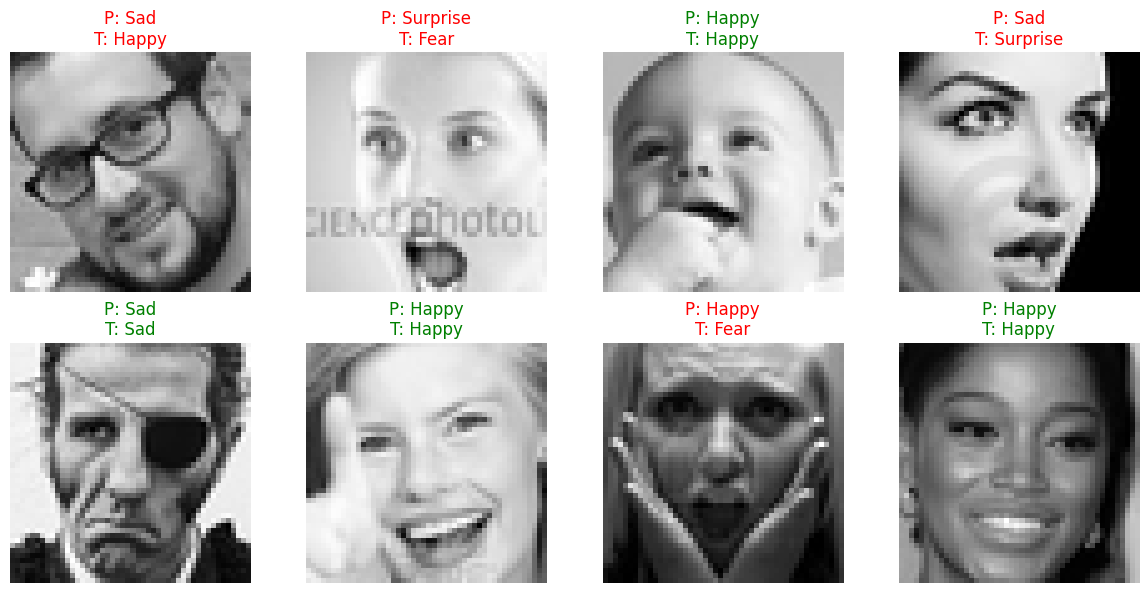

In [18]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import random
import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, SimpleCNN

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN()
model.load_state_dict(torch.load(ROOT / "best_model.pth", map_location=device))
model.eval()
model.to(device)

indices = random.sample(range(len(val_dataset)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    title = f"P: {FERDataset.class_names[pred]}\nT: {FERDataset.class_names[label]}"
    color = "green" if pred == label else "red"
    plt.title(title, color=color)

    plt.axis("off")

plt.tight_layout()
plt.show()

## Confusion Matrix

[[163   0  16  94 111  14  69]
 [ 21   0   3  10  19   0   3]
 [ 56   0  85  77 141  63  74]
 [ 35   0  15 693  69  13  70]
 [ 75   0  32  94 311  15 126]
 [ 19   0  27  29  29 282  29]
 [ 49   0  16  75 149  10 308]]


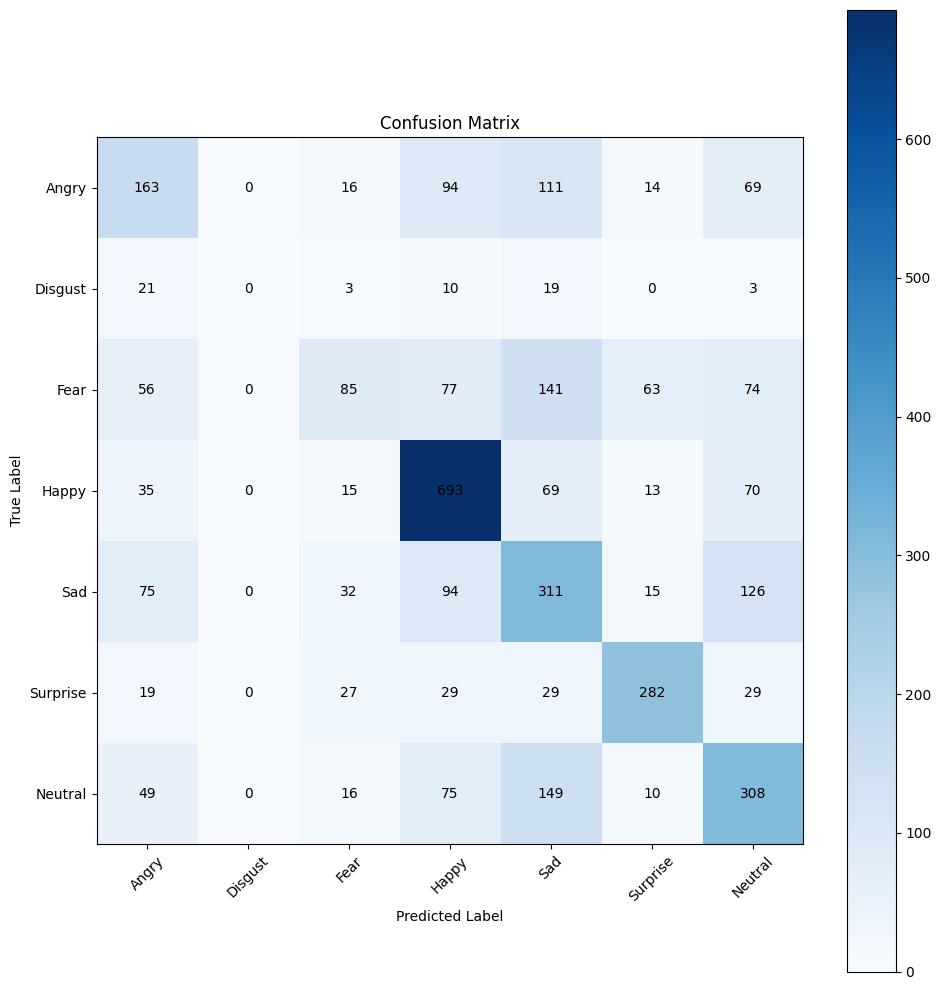

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

y_true = np.load(ROOT / "best_y_true.npy")
y_pred = np.load(ROOT / "best_y_pred.npy")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4, 5, 6])
print(cm)

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")

plt.tight_layout()
plt.show()

### Observations
- Happy has the strongest performance.
- Disjust has the least recognition.
- Negative emotions, such as anger, fear, and sadness, are often confused.

### Confusion pair analysis

In [8]:
import sys
from pathlib import Path

import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, SimpleCNN

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN()
model.load_state_dict(torch.load(ROOT / "best_model.pth", map_location=device))
model.eval()
model.to(device)

target_true = 2   # Fear
target_pred = 5   # Surprise

pair_indices = []

for idx in range(len(val_dataset)):
    image, label = val_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    if label == target_true and pred == target_pred:
        pair_indices.append(idx)

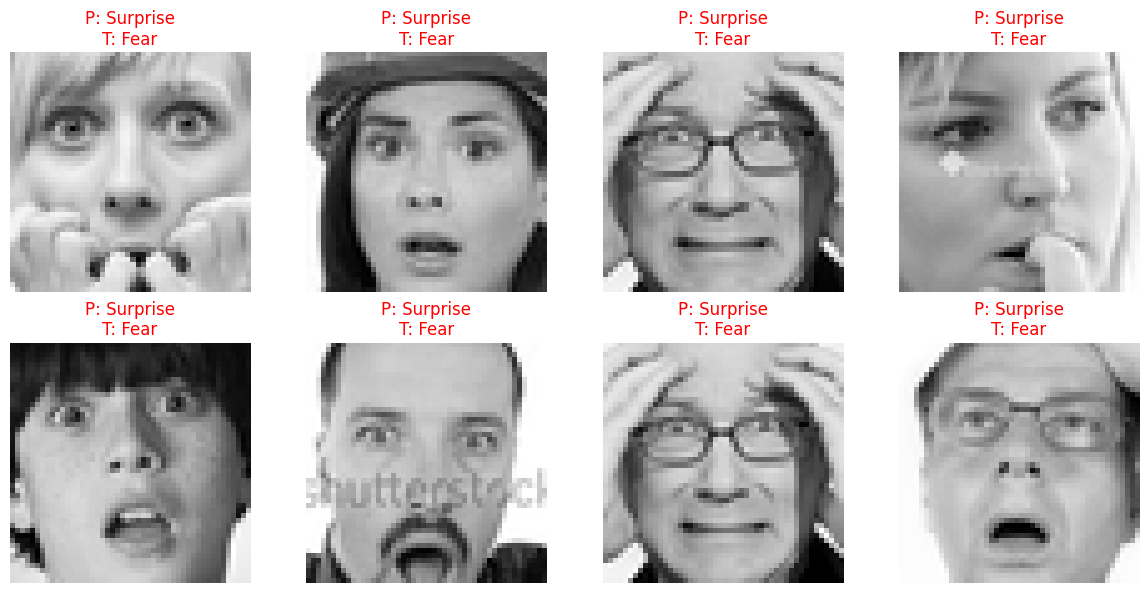

In [9]:
import matplotlib.pyplot as plt

sample_pair = pair_indices[:8]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_pair):
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"P: {FERDataset.class_names[pred]}\nT: {FERDataset.class_names[label]}", color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Grad-CAM Visualization

In [22]:
import sys
from pathlib import Path
import random
import matplotlib.pyplot as plt
import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))

from main import SimpleCNN, FERDataset
from gradcam import GradCAM

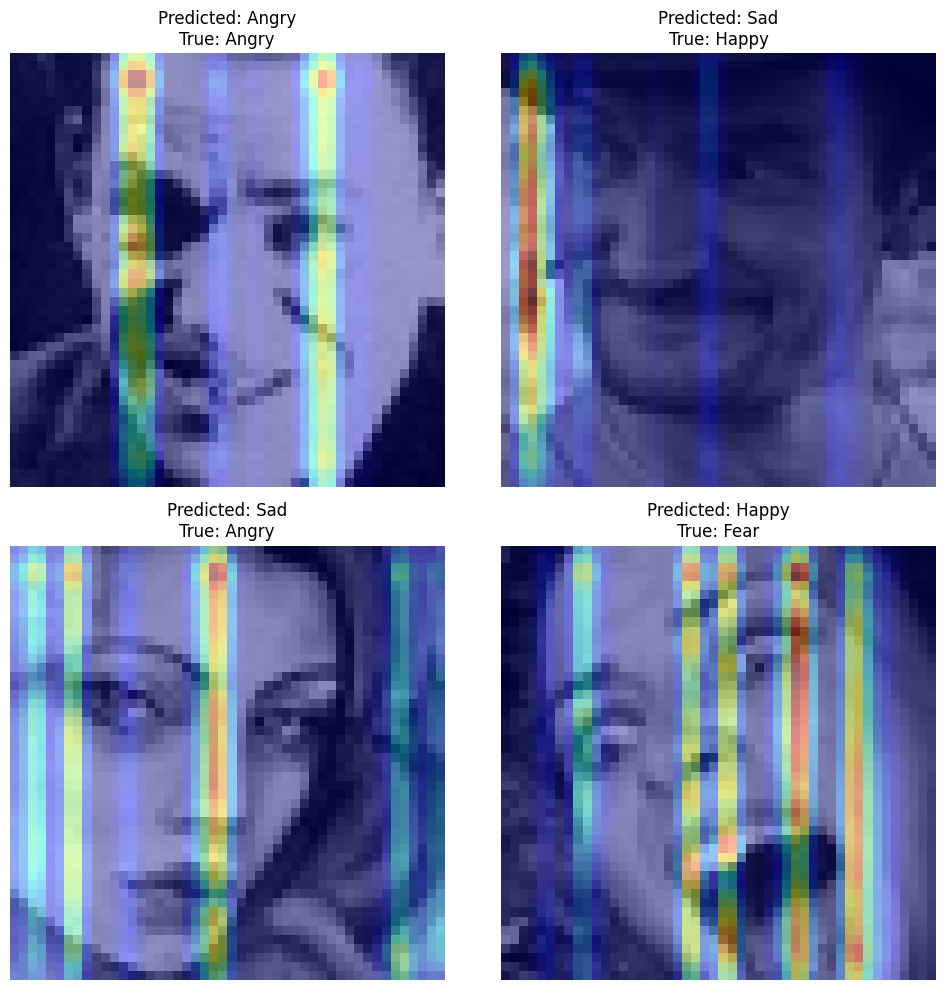

In [24]:
class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN()
model.load_state_dict(torch.load(ROOT / "best_model.pth", map_location=device))
model.eval()
model.to(device)

# initialize gradcam (last conv in SimpleCNN.features)
gradcam = GradCAM(model, model.features[3])

# get a random sample from the dataset
indices = random.sample(range(len(val_dataset)), 4)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    heatmap, class_idx = gradcam.generate(input_tensor, class_idx=pred)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image.squeeze().cpu().numpy(), cmap="gray")

    heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0).float()
    heatmap_resized = torch.nn.functional.interpolate(
        heatmap_tensor,
        size=image.squeeze().shape,
        mode="bilinear",
        align_corners=False,
    ).squeeze(0).squeeze(0).numpy()

    plt.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    plt.title(f"Predicted: {class_names[pred]}\nTrue: {class_names[label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
        

